# CIND820 Milestone 3 — Notebook 03: Feature Engineering
**Student:** Mubarak Ahmed (501345730)
**Pipeline Stage:** Stage 4 (Feature Engineering)

**Purpose:** Transform the cleaned train/test splits into model-ready feature matrices:
1. Categorical missing values → explicit `Unknown` category
2. Mode-stratified median imputation for freight cost and weight, with imputed-flag features
3. `log1p` transformation of the right-skewed monetary and weight fields
4. Chi-squared pre-selection of categorical features (α = 0.05, computed on the **training split only**)
5. One-hot encoding of retained categoricals
6. Vendor risk tier (train-fold historical on-time rate) and Mode × Tier interaction features

**Leakage prevention:** all transformations are implemented in a `FeatureEngineer` class
(`src/features.py`) with a strict fit/transform contract — `fit()` learns every statistic
(medians, selection decisions, encoder vocabulary, vendor tiers) from the training split only,
and `transform()` applies them unchanged to the test split.

In [1]:
# Section 1: Imports
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from features import FeatureEngineer

train_df = pd.read_parquet('../data/processed/train.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')
print(f"Train: {train_df.shape} | Test: {test_df.shape}")

Train: (8259, 14) | Test: (2065, 14)


## Section 2: Fit the feature engineering pipeline on the training split

In [2]:
# Fit on TRAIN ONLY — this is the structural leakage boundary
fe = FeatureEngineer(alpha=0.05)
fe.fit(train_df)

print("Fitted. Learned statistics:")
print(f"  Imputation medians learned per shipment mode (train only)")
print(f"  Vendor risk tier threshold (train on-time rate): {fe.tier_threshold_:.4f}")
print(f"  High-risk vendors: {sum(fe.vendor_tiers_.values())} of {len(fe.vendor_tiers_)}")

Fitted. Learned statistics:
  Imputation medians learned per shipment mode (train only)
  Vendor risk tier threshold (train on-time rate): 0.8851
  High-risk vendors: 7 of 69


## Section 3: Chi-squared pre-selection results (training split)

Note these statistics are computed on the **training split (n = 8,259)**, so the values differ
from the full-dataset exploratory figures in the Milestone 2 EDA (e.g., Vendor χ² = 575.64 on all
10,324 rows). This is deliberate: performing feature selection on the full dataset before
splitting would leak test-set information into the feature choice. The full-data EDA answered
"is there signal?"; this train-only test answers "which features may the model use?".

In [3]:
# Chi-squared audit table — the selection decision record
fe.chi2_results_.to_csv('../outputs/tables/chi2_feature_selection_train.csv', index=False)
print("Saved to outputs/tables/chi2_feature_selection_train.csv")
fe.chi2_results_

Saved to outputs/tables/chi2_feature_selection_train.csv


,feature,chi2,p_value,dof,selected
0,shipment mode,169.21,1.886189e-32,8,True
1,vendor,451.16,1.965884e-35,136,True
2,country,468.21,1.080384e-54,84,True
3,fulfill via,265.33,2.417946e-58,2,True
4,dosage form,167.73,2.507643e-20,32,True
5,sub classification,56.07,1.989208e-08,10,True


All six candidate categorical features reject the null hypothesis of independence at α = 0.05
and are retained. The one-hot encoded block is **142 columns — below the 150-column threshold
set in Milestone 2 — so the PCA contingency is not triggered** and full feature-level
interpretability is preserved for the SHAP analysis planned in the evaluation stage.

## Section 4: Transform both splits

In [4]:
# Apply learned transformations to train and test
X_train, y_train = fe.transform(train_df)
X_test, y_test = fe.transform(test_df)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"NaN check — train: {X_train.isna().any().any()} | test: {X_test.isna().any().any()}")
print(f"\nFeature block composition:")
print(f"  Numeric + imputed flags:      6")
print(f"  One-hot categorical:        142")
print(f"  Vendor risk tier:             1")
print(f"  Mode x Tier interactions:     5")
print(f"  Total:                      {X_train.shape[1]}")

X_train: (8259, 154) | X_test: (2065, 154)
NaN check — train: False | test: False

Feature block composition:
  Numeric + imputed flags:      6
  One-hot categorical:        142
  Vendor risk tier:             1
  Mode x Tier interactions:     5
  Total:                      154


In [5]:
# Imputation audit: how many values were imputed in each split?
imp_cols = ['freight cost_imputed', 'weight_imputed']
audit = pd.DataFrame({
    'train_imputed': [int(X_train[c].sum()) for c in imp_cols],
    'train_pct': [round(X_train[c].mean()*100, 1) for c in imp_cols],
    'test_imputed': [int(X_test[c].sum()) for c in imp_cols],
    'test_pct': [round(X_test[c].mean()*100, 1) for c in imp_cols],
}, index=imp_cols)
audit

,train_imputed,train_pct,test_imputed,test_pct
freight cost_imputed,1429,17.3,357,17.3
weight_imputed,1308,15.8,325,15.7


The imputed-flag features preserve the *informative missingness* signal identified in
preprocessing (e.g., freight absorbed into commodity cost clusters on specific modes): the model
can learn from the fact that a value was missing, not just from the imputed median.

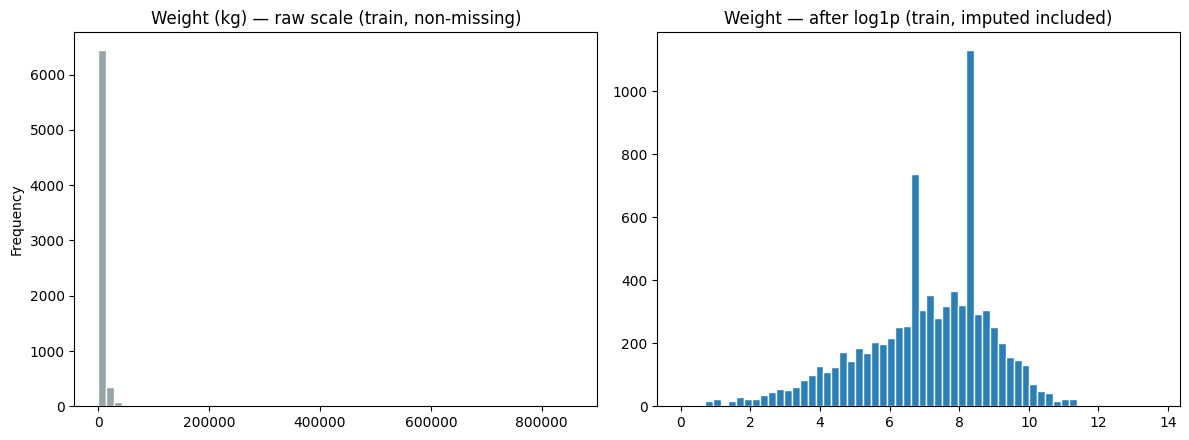

Figure saved to outputs/figures/log_transform_effect.png


In [6]:
# Visualize the effect of log1p on the skewed numeric predictors
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
raw_w = train_df['weight (kilograms)'].dropna()
axes[0].hist(raw_w, bins=60, color='#95a5a6', edgecolor='white')
axes[0].set_title('Weight (kg) — raw scale (train, non-missing)')
axes[0].set_ylabel('Frequency')
axes[1].hist(X_train['log1p_weight (kilograms)'], bins=60, color='#2980b9', edgecolor='white')
axes[1].set_title('Weight — after log1p (train, imputed included)')
plt.tight_layout()
plt.savefig('../outputs/figures/log_transform_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/log_transform_effect.png")

**Justification recap:** the raw distribution is extremely right-skewed (a small number of very
heavy consolidated shipments). `log1p` compresses this range so the logistic regression baseline
is not dominated by extreme-value leverage; tree-based models (Random Forest, XGBoost) are
scale-invariant, so applying the same transformation to all models keeps the comparison fair.

## Section 5: Vendor risk tier and interaction features

In [7]:
# Distribution of the engineered tier and interaction features (train)
tier_delay = train_df.assign(tier=X_train['vendor_risk_tier']).groupby('tier')['delay_class'].apply(
    lambda s: (s > 0).mean() * 100).round(1)
print("Delay rate (at-risk or delayed) by vendor risk tier — train split:")
print(f"  Low-risk vendors (tier 0):  {tier_delay[0]}%")
print(f"  High-risk vendors (tier 1): {tier_delay[1]}%")
print(f"\nShipments from high-risk vendors: {int(X_train['vendor_risk_tier'].sum()):,}"
      f" ({X_train['vendor_risk_tier'].mean()*100:.1f}% of train)")

Delay rate (at-risk or delayed) by vendor risk tier — train split:
  Low-risk vendors (tier 0):  1.3%
  High-risk vendors (tier 1): 16.2%

Shipments from high-risk vendors: 5,656 (68.5% of train)


## Section 6: Persist Stage 4 artifacts

In [8]:
# Save feature matrices, fitted pipeline object, and feature name list
X_train.assign(delay_class=y_train.values).to_parquet('../data/processed/X_train.parquet', index=False)
X_test.assign(delay_class=y_test.values).to_parquet('../data/processed/X_test.parquet', index=False)
joblib.dump(fe, '../outputs/models/feature_engineer.joblib')
pd.Series(fe.feature_names_, name='feature').to_csv('../outputs/tables/feature_names.csv', index=False)

print("Artifacts saved:")
print("  data/processed/X_train.parquet, X_test.parquet")
print("  outputs/models/feature_engineer.joblib  (fitted pipeline, reusable at inference)")
print("  outputs/tables/feature_names.csv")

Artifacts saved:
  data/processed/X_train.parquet, X_test.parquet
  outputs/models/feature_engineer.joblib  (fitted pipeline, reusable at inference)
  outputs/tables/feature_names.csv


## Section 7: Stage 4 Summary

| Check | Result |
|---|---|
| Chi-squared selection (train only) | All 6 candidates retained (all p < 0.001) |
| One-hot block width | 142 columns — under 150, PCA not triggered |
| Final feature matrix | 154 features, zero NaN in train and test |
| Imputation | Mode-stratified medians (train-learned) + imputed flags |
| Vendor risk tier | 7 of 69 vendors below the 88.5% network on-time rate |
| Leakage | All statistics fitted on train split only, via FeatureEngineer class |

**Next:** Notebook 04 — model training: logistic regression baseline, Random Forest, XGBoost,
stratified 5-fold cross-validation, class-weight vs SMOTE comparison.